In [ ]:
import os
import json

# ── Monter Google Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Dossiers du projet CNN
PROJECT_DIR = '/content/drive/MyDrive/FinalCNN'
DATASET_DIR = f'{PROJECT_DIR}/datasets'
MODEL_DIR   = f'{PROJECT_DIR}/models'
RESULTS_DIR = f'{PROJECT_DIR}/results'

for d in [PROJECT_DIR, DATASET_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive monté")

# ── Configurer Kaggle ─────────────────────────────────────────
KAGGLE_USERNAME = "username"
KAGGLE_KEY      = "Kaggle_Key"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle -q

print("\n Kaggle est bien configuré")

Mounted at /content/drive
Drive monté

 Kaggle est bien configuré


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import gc
import psutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder, MinMaxScaler
from sklearn.metrics            import (classification_report,
                                         confusion_matrix,
                                         accuracy_score,
                                         f1_score,
                                         roc_auc_score,
                                         roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow                 import keras
from tensorflow.keras           import layers, regularizers, callbacks
from tensorflow.keras.utils     import to_categorical

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Fonction RAM
def check_ram():
    ram  = psutil.virtual_memory()
    free = ram.available / 1e9
    used = ram.used / 1e9
    tot  = ram.total / 1e9
    print(f"RAM : {used:.1f}GB utilisés "
          f"| {free:.1f}GB libres | {tot:.1f}GB total")
    if free < 1.5:
        gc.collect()

In [ ]:
import os
import glob

csv_in_drive = glob.glob(f'{DATASET_DIR}/*.csv')

if csv_in_drive:
    print(f"Dataset déjà dans Drive ({len(csv_in_drive)} fichiers)")
    for f in csv_in_drive:
        size = os.path.getsize(f) / 1e6
        print(f"{os.path.basename(f)} → {size:.1f} MB")

else:

    os.makedirs('/content/cicids_raw', exist_ok=True)

    !kaggle datasets download \
        -d chethuhn/network-intrusion-dataset \
        -p /content/cicids_raw -q

    print(" Téléchargement du DATASET est terminé")
    print(" Décompression")

    import zipfile
    zip_path = '/content/cicids_raw/network-intrusion-dataset.zip'

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_csv = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"\n   Fichiers disponibles ({len(all_csv)}) :")
        for f in all_csv:
            size = z.getinfo(f).file_size / 1e6
            print(f"{f} → {size:.1f} MB")

        target = next(
            (f for f in all_csv if 'Wednesday' in f
             or 'wednesday' in f),
            all_csv[0]
        )
        print(f"\n Extraction : {target}")
        z.extract(target, '/content/cicids_raw/')

    extracted = glob.glob('/content/cicids_raw/*.csv')
    for f in extracted:
        dest = f'{DATASET_DIR}/{os.path.basename(f)}'
        !cp "{f}" "{dest}"
        print(f"Sauvegardé : {os.path.basename(f)}")

    !rm -rf /content/cicids_raw
    gc.collect()
    print("Dataset prêt dans Drive")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
 Téléchargement du DATASET est terminé
 Décompression

   Fichiers disponibles (8) :
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 77.1 MB
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 76.9 MB
Friday-WorkingHours-Morning.pcap_ISCX.csv → 58.3 MB
Monday-WorkingHours.pcap_ISCX.csv → 176.9 MB
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 83.1 MB
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 52.0 MB
Tuesday-WorkingHours.pcap_ISCX.csv → 135.1 MB
Wednesday-workingHours.pcap_ISCX.csv → 225.2 MB

 Extraction : Wednesday-workingHours.pcap_ISCX.csv
Sauvegardé : Wednesday-workingHours.pcap_ISCX.csv
Dataset prêt dans Drive


In [ ]:
import pandas as pd
import numpy as np
import gc
import glob
import os

def map_label(lbl):
    lbl = str(lbl).upper().strip()
    if 'BENIGN'   in lbl:                   return 'BENIGN'
    if 'DOS'      in lbl or 'DDOS' in lbl:  return 'DoS'
    if 'PORTSCAN' in lbl or 'SCAN' in lbl:  return 'Probe'
    if 'BRUTE'    in lbl or 'FTP'  in lbl \
       or 'SSH'   in lbl:                   return 'R2L'
    if 'BOT'      in lbl:                   return 'Bot'
    if 'WEB'      in lbl or 'SQL'  in lbl \
       or 'XSS'   in lbl:                   return 'WebAttack'
    if 'INFILTR'  in lbl:                   return 'U2R'
    if 'HEART'    in lbl:                   return 'DoS'
    return 'Other'

csv_files = glob.glob(f'{DATASET_DIR}/*.csv')
print(f"Fichier : {os.path.basename(csv_files[0])}")

CHUNK_SIZE = 50000
MAX_LIGNES = 200000

print(f"\n Lecture par chunks ({CHUNK_SIZE:,} lignes)")

frames = []
total  = 0

for i, chunk in enumerate(pd.read_csv(
        csv_files[0],
        chunksize=CHUNK_SIZE,
        low_memory=False)):

    chunk.columns = chunk.columns.str.strip()
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    lbl_col = next(
        (c for c in chunk.columns if 'label' in c.lower()),
        None
    )
    if lbl_col is None:
        continue

    chunk[lbl_col] = chunk[lbl_col].apply(map_label)
    chunk.rename(columns={lbl_col: 'label'}, inplace=True)

    frames.append(chunk)
    total += len(chunk)
    print(f"   Chunk {i+1} : {total:,} lignes")

    if total >= MAX_LIGNES:
        print(f"Limite atteinte → arrêt")
        break

df = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

print(f"\n Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n Distribution :")
print(df['label'].value_counts())

check_ram()

Fichier : Wednesday-workingHours.pcap_ISCX.csv

 Lecture par chunks (50,000 lignes)
   Chunk 1 : 50,000 lignes
   Chunk 2 : 100,000 lignes
   Chunk 3 : 150,000 lignes
   Chunk 4 : 200,000 lignes
Limite atteinte → arrêt

 Dataset : 200,000 lignes × 79 colonnes

 Distribution :
label
DoS       129971
BENIGN     70029
Name: count, dtype: int64
RAM : 1.8GB utilisés | 11.5GB libres | 13.6GB total


In [ ]:
import numpy as np
import gc
import psutil
import tensorflow as tf
from sklearn.preprocessing   import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils  import to_categorical

gc.collect()
tf.keras.backend.clear_session()

print("PRÉTRAITEMENT CNN")
check_ram()

# ── A. Séparer features et labels ───────────────────────────────
print("\n[A] Séparation features / labels...")

drop_cols = ['label']
feat_cols = [
    c for c in df.columns
    if c not in drop_cols
    and df[c].dtype in [np.float64, np.float32,
                         np.int64, np.int32]
]

X_raw = df[feat_cols].values.astype(np.float32)
y_raw = df['label'].values.copy()

del df
gc.collect()

print(f"Features : {X_raw.shape[1]}")
print(f"Lignes   : {X_raw.shape[0]:,}")
check_ram()

# ── B. Nettoyage ─────────────────────────────────────────────────
print("\n[B] Nettoyage...")

X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = X_raw.astype(np.float32)

col_medians = np.nanmedian(X_raw, axis=0)
nan_mask    = np.isnan(X_raw)
for j in range(X_raw.shape[1]):
    X_raw[nan_mask[:, j], j] = col_medians[j]

std_vals       = np.std(X_raw, axis=0)
good_cols      = std_vals > 0
X_raw          = X_raw[:, good_cols]
feat_cols_kept = [feat_cols[i]
                  for i in range(len(feat_cols)) if good_cols[i]]

gc.collect()
print(f"Features après nettoyage : {X_raw.shape[1]}")

# ── C. Encoder les labels ────────────────────────────────────────
print("\n[C] Encodage des labels...")

le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
N_CLASSES   = len(le.classes_)
CLASS_NAMES = list(le.classes_)

del y_raw
gc.collect()

print(f"Nombre de classes : {N_CLASSES}")
for i, cls in enumerate(CLASS_NAMES):
    count = int((y_enc == i).sum())
    pct   = count / len(y_enc) * 100
    print(f"      {cls:<12} : {count:,} ({pct:.1f}%)")

# ── D. Sélection features par variance ──────────────────────────
print("\n[D] Sélection des meilleures features...")

N_TOP = 40

variances   = np.var(X_raw, axis=0)
top_indices = np.argsort(variances)[::-1][:N_TOP]
X_selected  = X_raw[:, top_indices].astype(np.float32)
FEAT_NAMES  = [feat_cols_kept[i] for i in top_indices]
K           = X_selected.shape[1]

del X_raw
gc.collect()

print(f"Features sélectionnées : {K}")
print(f"Top 5 : {FEAT_NAMES[:5]}")
check_ram()

# ── E. Split train / val / test ──────────────────────────────────
print("\n[E] Split des données...")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y_enc,
    test_size=0.15,
    random_state=SEED,
    stratify=y_enc
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.12,
    random_state=SEED,
    stratify=y_tr
)

del X_selected, y_enc
gc.collect()

print(f"Train      : {X_tr.shape[0]:,}")
print(f"Validation : {X_val.shape[0]:,}")
print(f"Test       : {X_te.shape[0]:,}")

# ── F. Normalisation MinMaxScaler ────────────────────────────────
print("\n[F] Normalisation MinMaxScaler")
# MinMaxScaler → valeurs entre [0, 1]
# Meilleur que RobustScaler pour Conv1D
scaler = MinMaxScaler()
X_tr   = scaler.fit_transform(X_tr).astype(np.float32)
X_val  = scaler.transform(X_val).astype(np.float32)
X_te   = scaler.transform(X_te).astype(np.float32)

print("Normalisation est bien terminée")

# ── G. Reshape 3D pour CNN ───────────────────────────────────────
print("\n[G] Reshape (N, K) → (N, K, 1) pour Conv1D...")
# DIFFÉRENCE PRINCIPALE avec le DNN
# Conv1D attend : (batch, timesteps, channels)
# → timesteps = K features
# → channels  = 1 (une seule "vue" des features)
X_tr_cnn  = X_tr.reshape(-1, K, 1)
X_val_cnn = X_val.reshape(-1, K, 1)
X_te_cnn  = X_te.reshape(-1, K, 1)

# Libérer les versions 2D
del X_tr, X_val, X_te
gc.collect()

print(f"Forme CNN : {X_tr_cnn.shape}")
print(f"(N échantillons, {K} features, 1 canal)")

# ── H. One-Hot Encoding ─────────────────────────────────────────────────
print("\n[H] One-Hot Encoding...")

y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
y_val_cat = to_categorical(y_val, N_CLASSES)
y_te_cat  = to_categorical(y_te,  N_CLASSES)

# ── Résumé ──
print(f"  X_train CNN : {X_tr_cnn.shape}")
print(f"  X_val   CNN : {X_val_cnn.shape}")
print(f"  X_test  CNN : {X_te_cnn.shape}")
print(f"  Classes     : {CLASS_NAMES}")
check_ram()

PRÉTRAITEMENT CNN
RAM : 1.8GB utilisés | 11.5GB libres | 13.6GB total

[A] Séparation features / labels...
Features : 78
Lignes   : 200,000
RAM : 1.8GB utilisés | 11.4GB libres | 13.6GB total

[B] Nettoyage...
Features après nettoyage : 68

[C] Encodage des labels...
Nombre de classes : 2
      BENIGN       : 70,029 (35.0%)
      DoS          : 129,971 (65.0%)

[D] Sélection des meilleures features...
Features sélectionnées : 40
Top 5 : ['Fwd IAT Total', 'Flow Duration', 'Idle Max', 'Idle Min', 'Fwd IAT Max']
RAM : 1.8GB utilisés | 11.5GB libres | 13.6GB total

[E] Split des données...
Train      : 149,600
Validation : 20,400
Test       : 30,000

[F] Normalisation MinMaxScaler
Normalisation est bien terminée

[G] Reshape (N, K) → (N, K, 1) pour Conv1D...
Forme CNN : (149600, 40, 1)
(N échantillons, 40 features, 1 canal)

[H] One-Hot Encoding...
  X_train CNN : (149600, 40, 1)
  X_val   CNN : (20400, 40, 1)
  X_test  CNN : (30000, 40, 1)
  Classes     : ['BENIGN', 'DoS']
RAM : 1.8GB uti

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import gc

gc.collect()

def build_cnn(seq_len, n_classes):
    """
    Construit le CNN 1D pour la détection d'intrusions.
    seq_len   : longueur de la séquence (= K features = 40)
    n_classes : nombre de classes (7)
    """

    inputs = keras.Input(shape=(seq_len, 1), name='input')

    # ══ BLOC CONV 1 : 64 filtres ════════════════════════════════
    # kernel_size=3 : regarde 3 features à la fois
    # padding='same' : garde la même taille de sortie
    x = layers.Conv1D(
            64, kernel_size=3, padding='same',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='conv1'
        )(inputs)
    x = layers.BatchNormalization(name='bn_c1')(x)
    x = layers.Activation('relu', name='relu_c1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)
    x = layers.Dropout(0.25, name='drop_c1')(x)

    # ══ BLOC CONV 2 : 128 filtres ═══════════════════════════════
    x = layers.Conv1D(
            128, kernel_size=3, padding='same',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='conv2'
        )(x)
    x = layers.BatchNormalization(name='bn_c2')(x)
    x = layers.Activation('relu', name='relu_c2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)
    x = layers.Dropout(0.30, name='drop_c2')(x)

    # ══ BLOC CONV 3 : 256 filtres ═══════════════════════════════
    x = layers.Conv1D(
            256, kernel_size=3, padding='same',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='conv3'
        )(x)
    x = layers.BatchNormalization(name='bn_c3')(x)
    x = layers.Activation('relu', name='relu_c3')(x)
    x = layers.Dropout(0.30, name='drop_c3')(x)

    # GlobalAveragePooling : résumé compact de toute la séquence
    # Plus robuste que Flatten contre l'overfitting
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dropout(0.35, name='drop_gap')(x)

    # ══ COUCHES DENSES ══════════════════════════════════════════
    x = layers.Dense(
            128,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='fc1'
        )(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.30, name='drop_fc1')(x)

    x = layers.Dense(
            64,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='fc2'
        )(x)
    x = layers.BatchNormalization(name='bn_fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)
    x = layers.Dropout(0.20, name='drop_fc2')(x)

    # ══ SORTIE ══════════════════════════════════════════════════
    outputs = layers.Dense(
        n_classes,
        activation='softmax',
        name='output'
    )(x)

    model = keras.Model(inputs, outputs, name='IDS_CNN')
    return model

# Construire le modèle
model_cnn = build_cnn(K, N_CLASSES)
model_cnn.summary()

print(f"\n Modèle CNN construit")
print(f"   Paramètres : {model_cnn.count_params():,}")
print(f"   Input shape : ({K}, 1)")
print(f"   Output      : ({N_CLASSES},) → {CLASS_NAMES}")

Model: "IDS_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_c1 (BatchNormalization)      │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_c1 (Activation)            │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_c1 (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_c2 (BatchNormalization)      │ (None, 20, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_c2 (Activation)            │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_c2 (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_c3 (BatchNormalization)      │ (None, 10, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_c3 (Activation)            │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_c3 (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_gap (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc1 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc2 (BatchNormalization)     │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc2 (Activation)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc2 (Dropout)              │ (None, 64)             │             

 Total params: 167,362 (653.76 KB)

 Trainable params: 166,082 (648.76 KB)

 Non-trainable params: 1,280 (5.00 KB)


 Modèle CNN construit
   Paramètres : 167,362
   Input shape : (40, 1)
   Output      : (2,) → ['BENIGN', 'DoS']


In [ ]:
import gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks
from sklearn.utils.class_weight import compute_class_weight

gc.collect()
tf.keras.backend.clear_session()

# Reconstruire après clear_session
model_cnn = build_cnn(K, N_CLASSES)
print("Modèle CNN reconstruit")

# ── Class weights ────────────────────────────────────────────────
cw = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
class_weight_dict = dict(enumerate(cw))
print("\n Class weights :")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, cw)):
    print(f"   {cls:<12} : {w:.3f}")

# ── Paramètres ───────────────────────────────────────────────────
EPOCHS     = 60
BATCH_SIZE = 128   # ← plus petit que DNN (données 3D plus lourdes)
LR         = 1e-3  # ← float simple (PAS CosineDecay !)

print(f"\n Époques    : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR initial : {LR}")
print(f"   Input CNN  : {X_tr_cnn.shape}")

# ── Compilation ──────────────────────────────────────────────────
# LR = float → compatible avec ReduceLROnPlateau
# Pas de F1 custom → erreur Keras 3
# F1 calculé avec sklearn dans Cellule 8
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("\n Modèle compilé")

# ── Callbacks ────────────────────────────────────────────────────
BEST_MODEL = f'{MODEL_DIR}/best_cnn.keras'

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: gc.collect()
    )
]

# ── tf.data.Dataset ──────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_tr_cnn, y_tr_cat)
).shuffle(
    buffer_size=5000,
    seed=SEED
).batch(BATCH_SIZE
).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_cnn, y_val_cat)
).batch(BATCH_SIZE
).prefetch(AUTOTUNE)

print("tf.data.Dataset prêt")
check_ram()

# ── Entraînement ─────────────────────────────────────────────────

history = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

del train_ds, val_ds
gc.collect()

print(f"\n Entraînement terminé ")
print(f"Modèle : {BEST_MODEL}")
check_ram()

Modèle CNN reconstruit

 Class weights :
   BENIGN       : 1.428
   DoS          : 0.769

 Époques    : 60
   Batch size : 128
   LR initial : 0.001
   Input CNN  : (149600, 40, 1)

 Modèle compilé
tf.data.Dataset prêt
RAM : 2.0GB utilisés | 11.3GB libres | 13.6GB total
Epoch 1/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.8774 - auc: 0.9440 - loss: 0.4962 - precision: 0.8774 - recall: 0.8774 - val_accuracy: 0.9143 - val_auc: 0.9750 - val_loss: 0.4184 - val_precision: 0.9143 - val_recall: 0.9143 - learning_rate: 0.0010
Epoch 2/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9178 - auc: 0.9726 - loss: 0.3898 - precision: 0.9178 - recall: 0.9178 - val_accuracy: 0.9282 - val_auc: 0.9851 - val_loss: 0.3596 - val_precision: 0.9282 - val_recall: 0.9282 - learning_rate: 0.0010
Epoch 3/60
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9253 - auc: 0.9787 - loss: 0.3516 - precision: 0.9253 - recall: 0.9253 - val_accuracy: 0.9336 - val_auc: 0.9884 - val_loss:

In [ ]:
import numpy as np
import gc
import tensorflow as tf
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
from tensorflow.keras.utils import to_categorical

gc.collect()

print("  Évaluation sue le jeu de test")

# Prédictions sur X_te_cnn (forme 3D)
y_pred_proba = model_cnn.predict(
    X_te_cnn, batch_size=256, verbose=0
)
y_pred = np.argmax(y_pred_proba, axis=1)

# Métriques
acc  = accuracy_score(y_te, y_pred)
f1_w = f1_score(y_te, y_pred, average='weighted', zero_division=0)
f1_m = f1_score(y_te, y_pred, average='macro',    zero_division=0)

# AUC-ROC
try:
    y_te_bin = to_categorical(y_te, N_CLASSES)
    auc_list = []
    for i in range(N_CLASSES):
        if len(np.unique(y_te_bin[:, i])) > 1:
            auc_list.append(
                roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
            )
    auc_mean = float(np.mean(auc_list))
except Exception:
    auc_mean = 0.0

# Affichage
print(f"\n MÉTRIQUES GLOBALES :")
print(f"  Accuracy          : {acc*100:.2f} %")
print(f"  F1-Score Weighted : {f1_w*100:.2f} %")
print(f"  F1-Score Macro    : {f1_m*100:.2f} %")
print(f"  AUC-ROC moyen     : {auc_mean:.4f}")

print(f"\n RAPPORT PAR CLASSE :")
print(classification_report(
    y_te, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

CM = confusion_matrix(y_te, y_pred)

  Évaluation sue le jeu de test

 MÉTRIQUES GLOBALES :
  Accuracy          : 98.42 %
  F1-Score Weighted : 98.42 %
  F1-Score Macro    : 98.25 %
  AUC-ROC moyen     : 0.9985

 RAPPORT PAR CLASSE :
              precision    recall  f1-score   support

      BENIGN     0.9983    0.9566    0.9770     10504
         DoS     0.9771    0.9991    0.9880     19496

    accuracy                         0.9842     30000
   macro avg     0.9877    0.9779    0.9825     30000
weighted avg     0.9845    0.9842    0.9842     30000



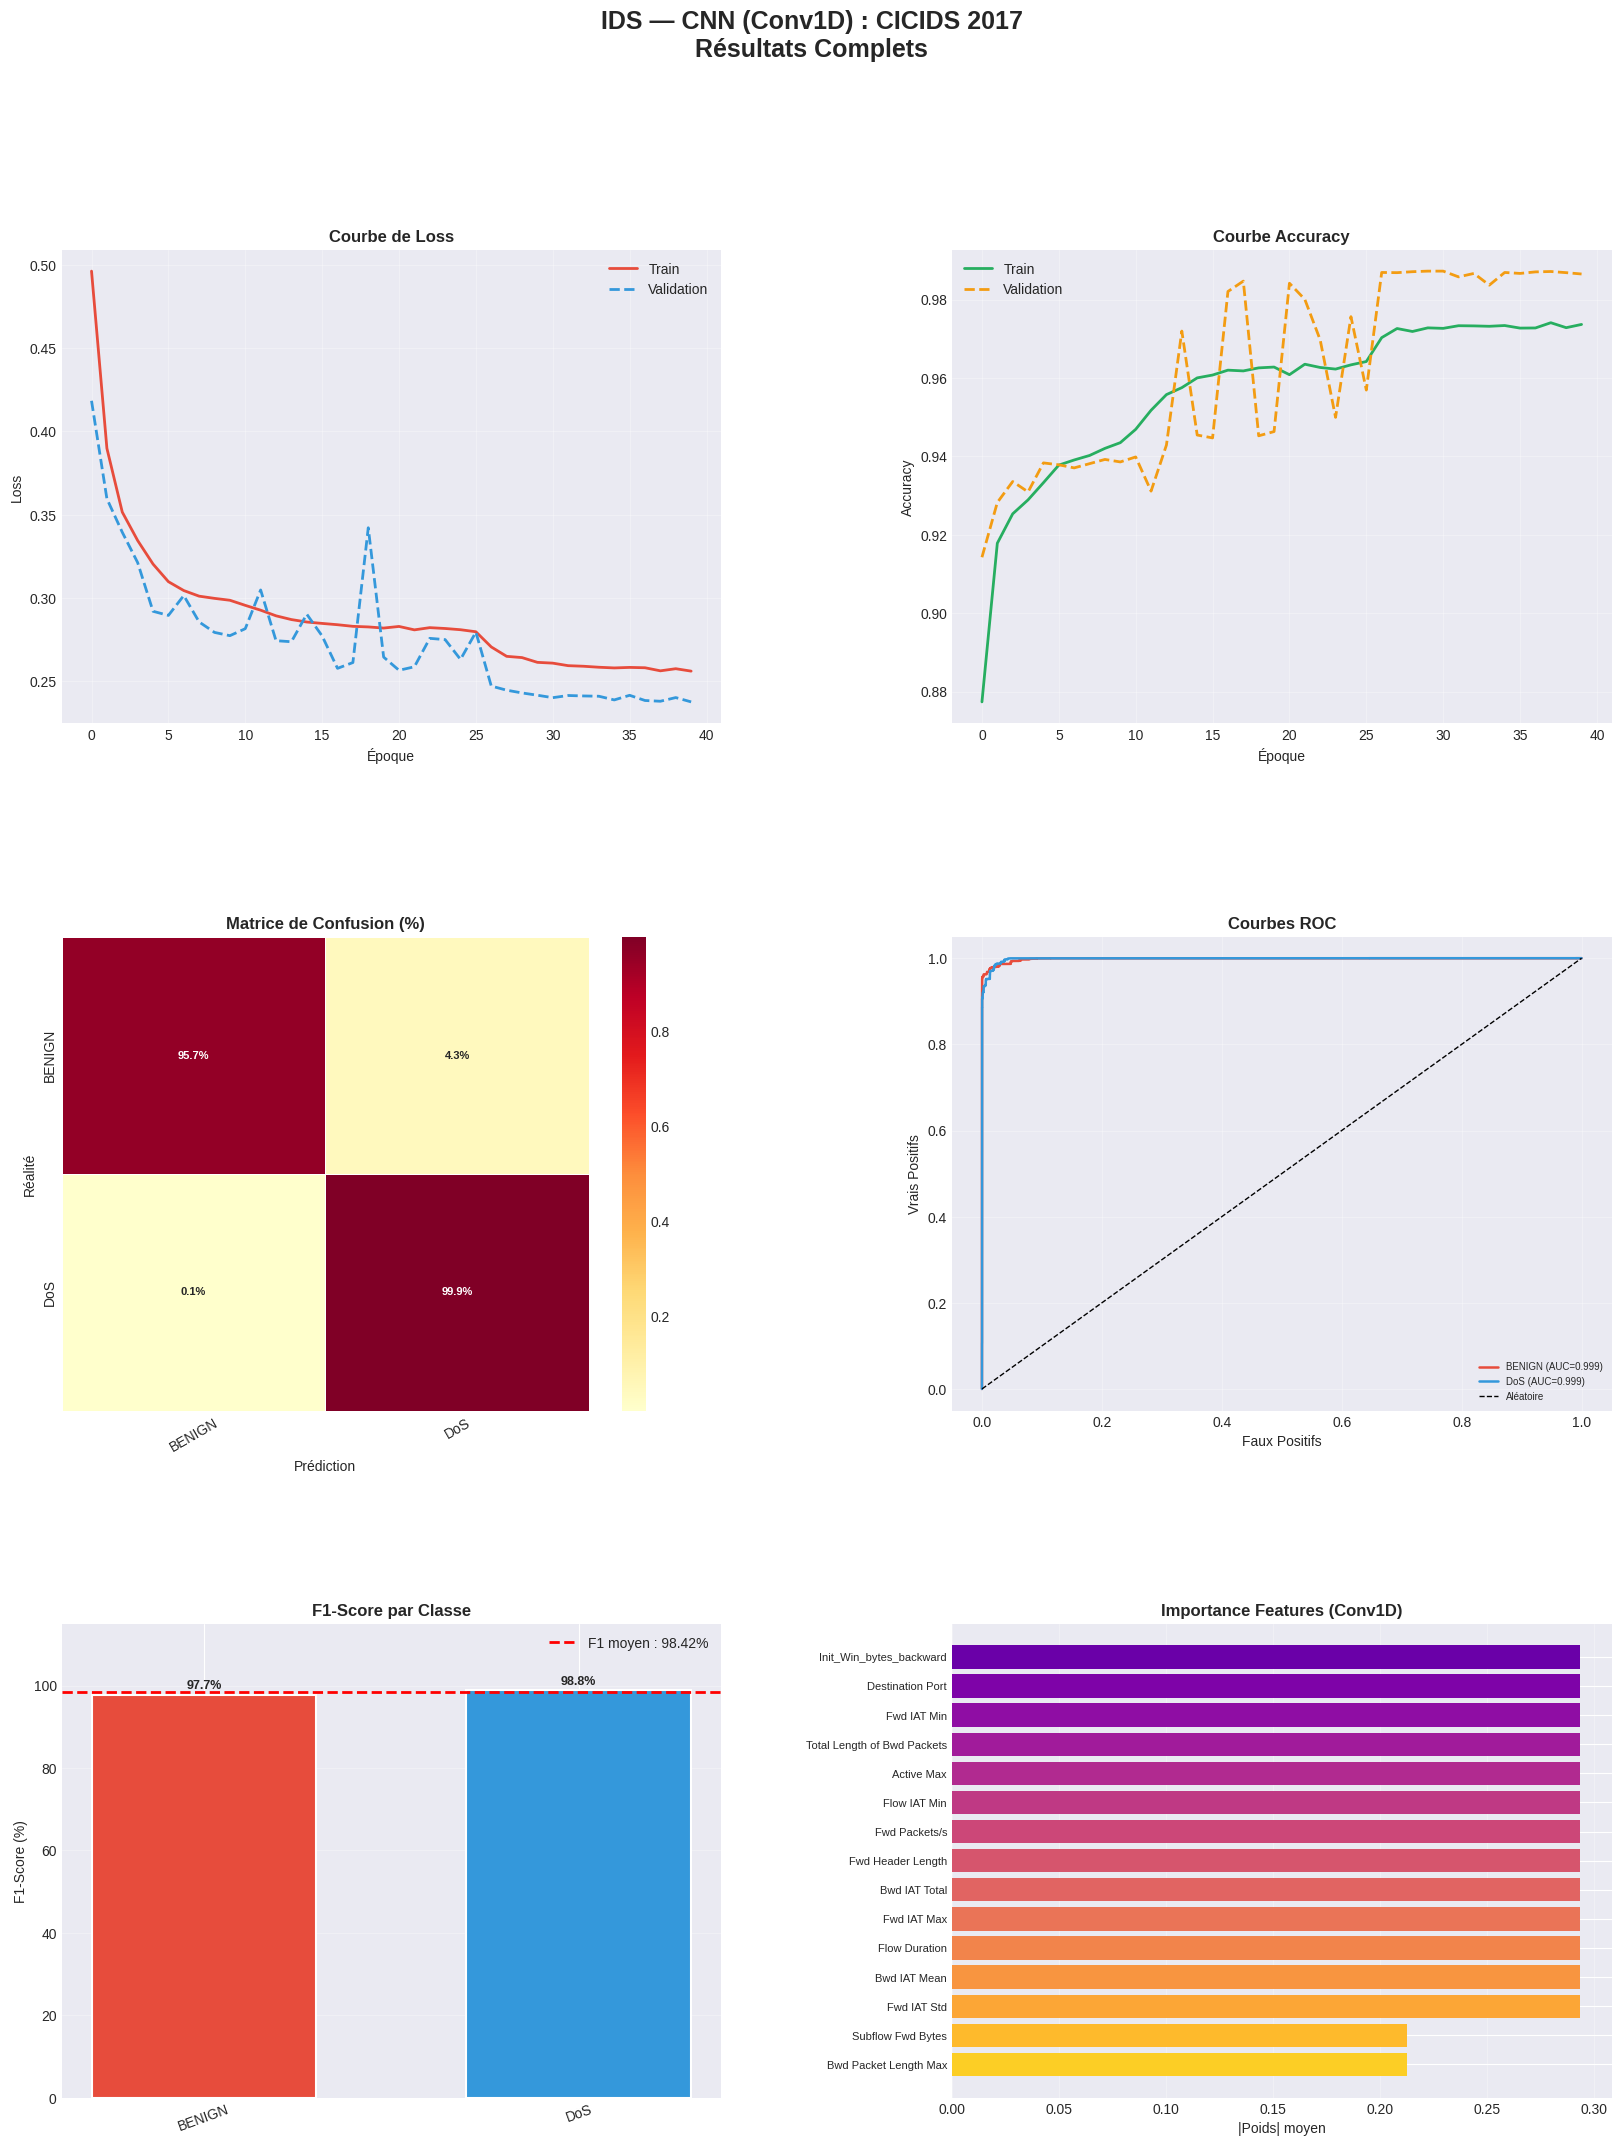

Graphes sauvegardés : /content/drive/MyDrive/FinalCNN/results/CNN_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import gc
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from tensorflow.keras.utils import to_categorical

plt.style.use('seaborn-v0_8-darkgrid')

PALETTE = ['#e74c3c','#3498db','#27ae60','#f39c12',
           '#8e44ad','#1abc9c','#e67e22']

fig = plt.figure(figsize=(20, 24))
fig.suptitle(
    'IDS — CNN (Conv1D) : CICIDS 2017\nRésultats Complets',
    fontsize=18, fontweight='bold'
)
gs = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── 1. Loss ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'],
         color='#e74c3c', lw=2, label='Train')
ax1.plot(history.history['val_loss'],
         color='#3498db', lw=2, ls='--', label='Validation')
ax1.set_title('Courbe de Loss', fontweight='bold', fontsize=12)
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 2. Accuracy ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['accuracy'],
         color='#27ae60', lw=2, label='Train')
ax2.plot(history.history['val_accuracy'],
         color='#f39c12', lw=2, ls='--', label='Validation')
ax2.set_title('Courbe Accuracy', fontweight='bold', fontsize=12)
ax2.set_xlabel('Époque')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── 3. Matrice de Confusion ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
cm_norm = CM.astype(float) / CM.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%',
    cmap='YlOrRd', ax=ax3,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    annot_kws={"size": 8, "weight": "bold"}
)
ax3.set_title('Matrice de Confusion (%)',
               fontweight='bold', fontsize=12)
ax3.set_xlabel('Prédiction')
ax3.set_ylabel('Réalité')
ax3.tick_params(axis='x', rotation=30)

# ── 4. Courbes ROC ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
y_te_bin = to_categorical(y_te, N_CLASSES)
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_pred_proba[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
    ax4.plot(fpr, tpr, color=color, lw=1.8,
             label=f'{cls_name} (AUC={auc_i:.3f})')
ax4.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax4.set_title('Courbes ROC', fontweight='bold', fontsize=12)
ax4.set_xlabel('Faux Positifs')
ax4.set_ylabel('Vrais Positifs')
ax4.legend(fontsize=7, loc='lower right')
ax4.grid(True, alpha=0.3)

# ── 5. F1 par classe ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)),
                   zero_division=0)
bars = ax5.bar(
    CLASS_NAMES, f1_cls * 100,
    color=[PALETTE[i % len(PALETTE)] for i in range(N_CLASSES)],
    edgecolor='white', linewidth=1.5, width=0.6
)
for bar, val in zip(bars, f1_cls):
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val*100:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax5.axhline(y=f1_w*100, color='red', ls='--', lw=2,
             label=f'F1 moyen : {f1_w*100:.2f}%')
ax5.set_title('F1-Score par Classe',
               fontweight='bold', fontsize=12)
ax5.set_ylabel('F1-Score (%)')
ax5.set_ylim(0, 115)
ax5.legend()
ax5.grid(True, axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=20)

# ── 6. Importance features (poids Conv1D) ───────────────────────
ax6 = fig.add_subplot(gs[2, 1])
try:
    # Poids du premier filtre Conv1D
    # forme : (kernel_size, 1, n_filters) = (3, 1, 64)
    w_conv = model_cnn.get_layer('conv1').get_weights()[0]
    # Importance = norme moyenne sur les filtres
    imp    = np.abs(w_conv).mean(axis=(1, 2))
    # Répéter pour couvrir toutes les features
    imp_full = np.tile(imp, int(np.ceil(K / len(imp))))[:K]
    top_idx  = np.argsort(imp_full)[::-1][:15]
    top_names = [FEAT_NAMES[i] if i < len(FEAT_NAMES)
                 else f'f{i}' for i in top_idx]
    top_vals  = imp_full[top_idx]
    colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, 15))
    ax6.barh(range(15), top_vals, color=colors_bar)
    ax6.set_yticks(range(15))
    ax6.set_yticklabels(top_names, fontsize=8)
    ax6.invert_yaxis()
    ax6.set_title('Importance Features (Conv1D)',
                   fontweight='bold', fontsize=12)
    ax6.set_xlabel('|Poids| moyen')
    ax6.grid(True, axis='x', alpha=0.3)
except Exception as e:
    ax6.text(0.5, 0.5, 'Non disponible',
             ha='center', va='center',
             transform=ax6.transAxes)

# ── Sauvegarde ───────────────────────────────────────────────────
GRAPH = f'{RESULTS_DIR}/CNN_results.png'
plt.tight_layout()
plt.savefig(GRAPH, dpi=150, bbox_inches='tight')
plt.show()

gc.collect()
print(f"Graphes sauvegardés : {GRAPH}")

In [ ]:
import gc
from sklearn.metrics import f1_score

gc.collect()

# Sauvegarder le modèle
FINAL = f'{MODEL_DIR}/CNN_final.keras'
model_cnn.save(FINAL)
print(f"Modèle sauvegardé : {FINAL}")

f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)),
                   zero_division=0)

summary = f"""
{'='*50}
  RÉSUMÉ — IDS basée CNN — CICIDS 2017
{'='*50}
  Accuracy          : {acc*100:.2f} %
  F1-Score Weighted : {f1_w*100:.2f} %
  F1-Score Macro    : {f1_m*100:.2f} %
  AUC-ROC moyen     : {auc_mean:.4f}
  Paramètres        : {model_cnn.count_params():,}
  Features          : {K}
  Input CNN         : ({K}, 1)
  Classes           : {CLASS_NAMES}
{'─'*50}
  F1 par classe :
"""
for cls, val in zip(CLASS_NAMES, f1_cls):
    bar = '█' * int(val * 20)
    summary += f"  {cls:<12} : {val*100:5.2f}%  {bar}\n"

summary += f"""{'─'*50}
  Architecture CNN :
  Input({K},1)
  → Conv1D(64)  + BN + ReLU + MaxPool
  → Conv1D(128) + BN + ReLU + MaxPool
  → Conv1D(256) + BN + ReLU
  → GlobalAvgPool
  → Dense(128) + Dense(64)
  → Softmax({N_CLASSES})
  Optimiseur : Adam LR=1e-3 + ReduceLROnPlateau
  Loss       : CategoricalCrossentropy (smoothing=0.1)
{'='*50}
"""

print(summary)

with open(f'{RESULTS_DIR}/CNN_summary.txt', 'w') as f:
    f.write(summary)

print(f"Résumé sauvegardé : {RESULTS_DIR}/CNN_summary.txt")
print(f"\n Fichiers dans Drive :")
print(f"   {MODEL_DIR}/CNN_final.keras")
print(f"   {RESULTS_DIR}/CNN_results.png")
print(f"   {RESULTS_DIR}/CNN_summary.txt")

Modèle sauvegardé : /content/drive/MyDrive/FinalCNN/models/CNN_final.keras

  RÉSUMÉ — IDS basée CNN — CICIDS 2017
  Accuracy          : 98.42 %
  F1-Score Weighted : 98.42 %
  F1-Score Macro    : 98.25 %
  AUC-ROC moyen     : 0.9985
  Paramètres        : 167,362
  Features          : 40
  Input CNN         : (40, 1)
  Classes           : ['BENIGN', 'DoS']
──────────────────────────────────────────────────
  F1 par classe :
  BENIGN       : 97.70%  ███████████████████
  DoS          : 98.80%  ███████████████████
──────────────────────────────────────────────────
  Architecture CNN :
  Input(40,1)
  → Conv1D(64)  + BN + ReLU + MaxPool
  → Conv1D(128) + BN + ReLU + MaxPool
  → Conv1D(256) + BN + ReLU
  → GlobalAvgPool
  → Dense(128) + Dense(64)
  → Softmax(2)
  Optimiseur : Adam LR=1e-3 + ReduceLROnPlateau
  Loss       : CategoricalCrossentropy (smoothing=0.1)

Résumé sauvegardé : /content/drive/MyDrive/FinalCNN/results/CNN_summary.txt

 Fichiers dans Drive :
   /content/drive/MyDrive/Fi